In [1]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import mysql.connector

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

In [3]:


conn = mysql.connector.connect(
    host="localhost",
    user="Mrunaliuser",
    password="Project@123",
    database="fake_job_detector"
)

query = "SELECT * FROM raw_job_posts"

df = pd.read_sql(query, conn)

conn.close()

print("✅ Dataset Loaded Successfully!")

C:\Users\Mrunali karmore\AppData\Local\Temp\ipykernel_3644\744232579.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


✅ Dataset Loaded Successfully!


In [4]:
df.shape

(17880, 19)

In [5]:
df.sample(10)

,id,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function_field,fraudulent
7733,7734,7734,Senior .Net Developer,"AE, DU, Dubai",IT,,"We're team of enthusiastic managers, programme...",If you are interested in using your technical ...,Minimum 3 years of experience.Expertise with C...,,0,1,1,,,,,,0
4903,4904,4904,Caregiver-Berrien County Michigan,"US, MI,",,,"""Our mission to our clients is to preserve the...",Home Sweet Home In-Home Care is currently seek...,Valid Driver’s LicenseValid Auto InsuranceReli...,Competitive CompensationOpportunity for Advanc...,0,1,1,,Entry level,High School or equivalent,Hospital & Health Care,Health Care Provider,0
8674,8675,8675,Live-in Caregiver with time off,"US, AZ, Scottsdale",,,,***Please do NOT apply for this position if yo...,"Candiates must have CPR/1st Aid, Experience as...","Free room and board, one 24 hour shift per wee...",0,0,1,Full-time,,Unspecified,,,0
973,974,974,iOS Developer (C++ focus),"US, NY, Brooklyn",,,"Our team is made of designers, physics wizards...",Dive deep into codeWe’re looking for an iOS De...,"You should have:A love of toys, games, puzzles...","What to expect:A collaborative, team-based app...",0,1,1,Full-time,,,,,0
13439,13440,13440,Consulting Delivery Leader - Sales Effectiveness,"US, CA, San Francisco",,,Talent Response connects flexible professional...,Company BackgroundTalent Response has partnere...,The ideal candidate will have:10+ years in com...,,0,1,1,Contract,Director,,Management Consulting,,0
366,367,367,Sales Director,"US, IL, Chicago",,,Visual BI is one of the leading and fastest gr...,City / Location : Any Hub City in the USA Join...,"New Business Development• Prospect, qualify an...",Salary and bonus commensurate with experience....,1,1,1,Full-time,Director,Associate Degree,Information Technology and Services,Sales,0
4221,4222,4222,Only GC or US Citizens// .Net Developer,"CA, , Rio Rancho, NM",,,Addon Technologies is a professional IT servic...,Job Title: .Net Developer Location: Rio Rancho...,,,0,1,1,,,,,,0
3644,3645,3645,Customer Service Representative,"US, FL, Tamarac",Call Center CSR,,,We are a leading outsourced contact solutions ...,As a Customer Service Representative you must ...,we are a dedicated family of professionals wit...,1,0,0,Full-time,Entry level,High School or equivalent,Computer Software,Customer Service,1
9971,9972,9972,Director of Engineering HMA Security Products,"US, CA, San Jose",Engineering,,NETGEAR and Aptitude Staffing Solutions have p...,Director of Engineering | HMA Security Product...,Skills and RequirementsMSEE with 5 years exper...,What Is Offered:Very competitive base salary.3...,0,1,1,Full-time,Director,Master's Degree,Telecommunications,Engineering,1
6004,6005,6005,Caregiver- Dowagiac/Cassopolis,"US, MI, Cassopolis Dowagiac",,,"""Our mission to our clients is to preserve the...",Home Sweet Home In-Home Care is currently seek...,,Competitive Compensation with performance revi...,0,1,1,Part-time,,,Hospital & Health Care,Health Care Provider,0


In [6]:
df.shape

(17880, 19)

In [7]:
df.columns

Index(['id', 'job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry',
       'function_field', 'fraudulent'],
      dtype='object')

In [8]:

df.info

<bound method DataFrame.info of           id job_id                                              title  \
0          1      1                                   Marketing Intern   
1          2      2          Customer Service - Cloud Video Production   
2          3      3            Commissioning Machinery Assistant (CMA)   
3          4      4                  Account Executive - Washington DC   
4          5      5                                Bill Review Manager   
...      ...    ...                                                ...   
17875  17876  17876                   Account Director - Distribution    
17876  17877  17877                                 Payroll Accountant   
17877  17878  17878  Project Cost Control Staff Engineer - Cost Con...   
17878  17879  17879                                   Graphic Designer   
17879  17880  17880                         Web Application Developers   

                   location   department salary_range  \
0          US, NY, New

In [9]:
import numpy as np


In [10]:
(df == "").sum()

id                         0
job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function_field          6455
fraudulent                 0
dtype: int64

In [11]:
import numpy as np

df = df.replace("", np.nan)

In [12]:
df.isnull().sum()

id                         0
job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function_field          6455
fraudulent                 0
dtype: int64

In [13]:

missing_percent = (
    df.isnull().sum() / len(df)
) * 100

missing_percent.sort_values(
    ascending=False
)

salary_range           83.959732
department             64.580537
required_education     45.329978
benefits               40.335570
required_experience    39.429530
function_field         36.101790
industry               27.421700
employment_type        19.412752
company_profile        18.501119
requirements           15.078300
location                1.935123
description             0.005593
title                   0.000000
id                      0.000000
job_id                  0.000000
telecommuting           0.000000
has_questions           0.000000
has_company_logo        0.000000
fraudulent              0.000000
dtype: float64

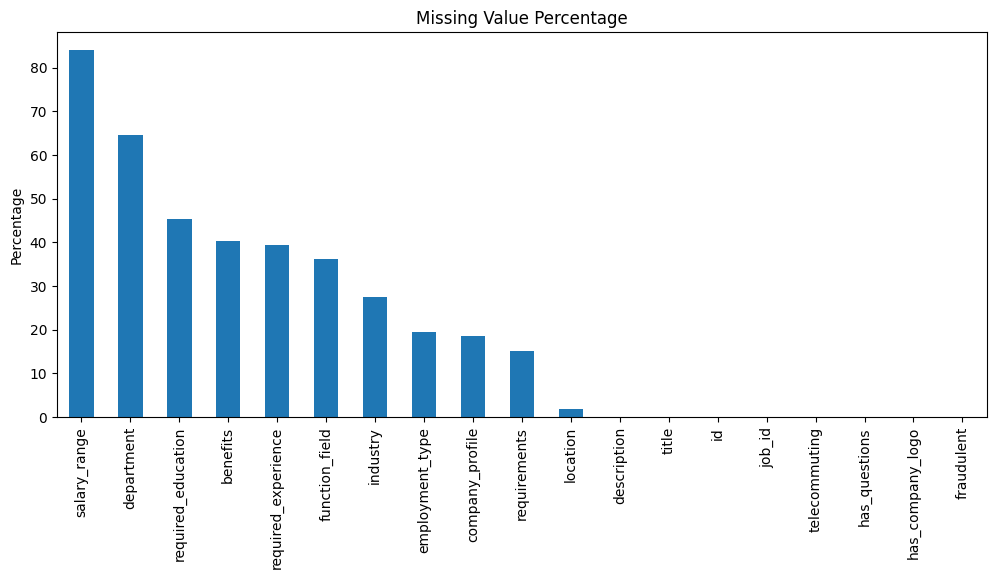

In [14]:
missing_percent.sort_values(
    ascending=False
).plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Missing Value Percentage")

plt.ylabel("Percentage")

plt.show()

In [15]:
df['fraudulent'].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

In [16]:
(
    df['fraudulent']
    .value_counts(normalize=True)
    * 100
)



fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64

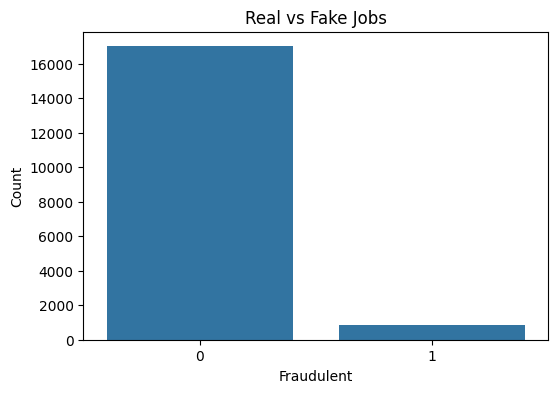

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='fraudulent',
    data=df
)

plt.title("Real vs Fake Jobs")

plt.xlabel("Fraudulent")

plt.ylabel("Count")

plt.show()

In [18]:
fake_jobs = df[
    df['fraudulent'] == 1
]

fake_jobs[
    ['title', 'description']
].head(3)

,title,description
98,IC&E Technician,"IC&amp;E Technician | Bakersfield, CA Mt. Poso..."
144,Forward Cap.,The group has raised a fund for the purchase o...
173,Technician Instrument & Controls,Technician Instrument &amp; ControlsLocation D...


In [19]:
real_jobs = df[
    df['fraudulent'] == 0
]

real_jobs[
    ['title', 'description']
].head(3)

,title,description
0,Marketing Intern,"Food52, a fast-growing, James Beard Award-winn..."
1,Customer Service - Cloud Video Production,Organised - Focused - Vibrant - Awesome!Do you...
2,Commissioning Machinery Assistant (CMA),"Our client, located in Houston, is actively se..."


In [20]:
df['text_length'] = (
    df['description']
    .astype(str)
    .apply(len)
)

In [21]:
df[
    ['description', 'text_length']
].head()

,description,text_length
0,"Food52, a fast-growing, James Beard Award-winn...",905
1,Organised - Focused - Vibrant - Awesome!Do you...,2077
2,"Our client, located in Houston, is actively se...",355
3,THE COMPANY: ESRI – Environmental Systems Rese...,2600
4,JOB TITLE: Itemization Review ManagerLOCATION:...,1520


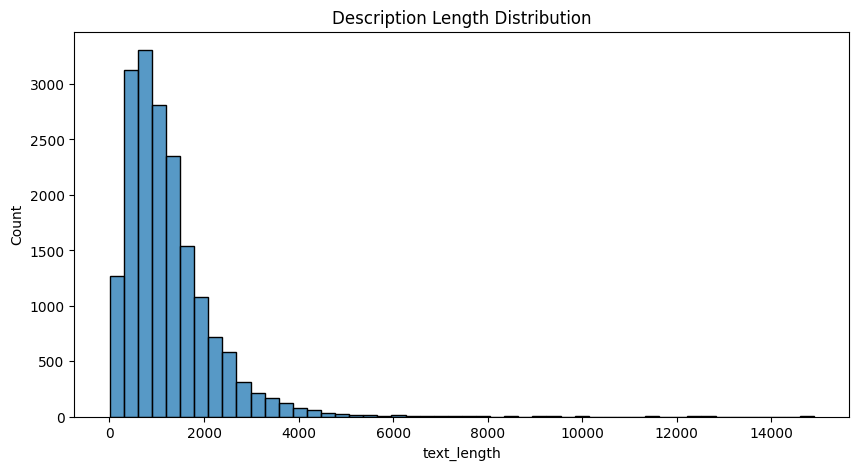

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['text_length'],
    bins=50
)

plt.title(
    "Description Length Distribution"
)

plt.show()

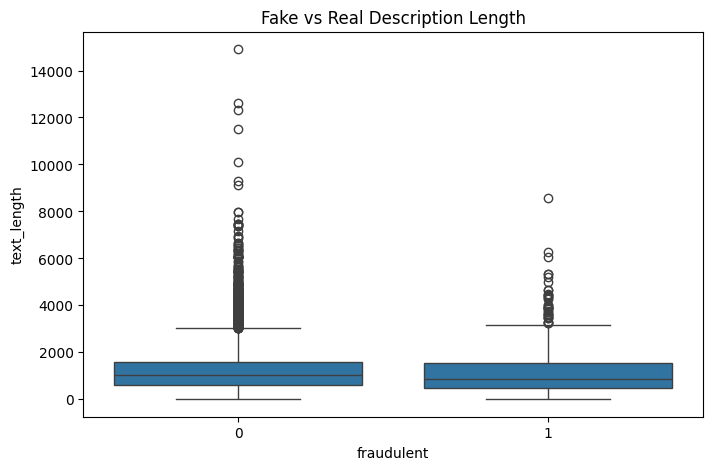

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='fraudulent',
    y='text_length',
    data=df
)

plt.title(
    "Fake vs Real Description Length"
)

plt.show()

In [24]:
df.groupby(
    'fraudulent'
)['text_length'].mean()

fraudulent
0    1221.219701
1    1154.838337
Name: text_length, dtype: float64

In [25]:
fake_text = " ".join(
    fake_jobs['description']
    .astype(str)
)

print(fake_text[:1000])

IC&amp;E Technician | Bakersfield, CA Mt. PosoPrincipal Duties and Responsibilities: Calibrates, tests, maintains, troubleshoots, and installs all power plant instrumentation, control systems and electrical equipment.Performs maintenance on motor control centers, motor operated valves, generators, excitation equipment and motors.Performs preventive, predictive and corrective maintenance on equipment, coordinating work with various team members.Designs and installs new equipment and/or system modifications.Troubleshoots and performs maintenance on DC backup power equipment, process controls, programmable logic controls (PLC), and emission monitoring equipment.Uses maintenance reporting system to record time and material use, problem identified and corrected, and further action required; provides complete history of maintenance on equipment.Schedule, coordinate, work with and monitor contractors on specific tasks, as required.Follows safe working practices at all times.Identifies safety 

In [26]:
df.shape

(17880, 20)

In [27]:
df.sample(5)

,id,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function_field,fraudulent,text_length
16909,16910,16910,Customer Service Positions,"US, TX, Carrollton",NaN,NaN,"LEI Home Enhancements, is an Ohio based compan...",Under the direction of your team's Marketing M...,YOU MUST HAVE: 1)Proficient PC skills incl...,WE OFFER:A competitive base plus commissions s...,0,1,0,Full-time,NaN,NaN,NaN,NaN,0,619
12348,12349,12349,Growth Expert,"FR, J, Paris",NaN,NaN,We Build Great CompanieseFounders is a startup...,eFounders is a startup Studio. Together with e...,The ideal candidateYou have 3 to 5 years of ex...,NaN,0,1,1,NaN,NaN,NaN,NaN,NaN,0,1190
10835,10836,10836,Customer Service Associate,"US, CA, Los Angeles",NaN,NaN,"Novitex Enterprise Solutions, formerly Pitney ...",The Customer Service Associate will be based i...,Required Qualifications:Demonstrated expertise...,NaN,0,1,0,Full-time,Entry level,High School or equivalent,Legal Services,Customer Service,0,2488
2436,2437,2437,SENIOR SOFTWARE ENGINEER,"US, CA, San Francisco",NaN,NaN,NaN,We pay competitive salaries and we offer meani...,Job Qualifications:#URL_968b3a839b798052f33a95...,Healthcare BenefitsAll your standard HMO/PPO a...,0,0,0,Full-time,Associate,Bachelor's Degree,Computer Software,Information Technology,0,1185
2640,2641,2641,Senior Web Analyst,"GR, I, Acharnai",Search & Social,NaN,Mindworks interactive is one of the fastest gr...,Mindworks is looking for a Senior Web Analyst ...,Client Management &amp; CommunicationBuild and...,CompensationWe offer competitive salaries base...,0,1,1,NaN,NaN,NaN,NaN,NaN,0,813


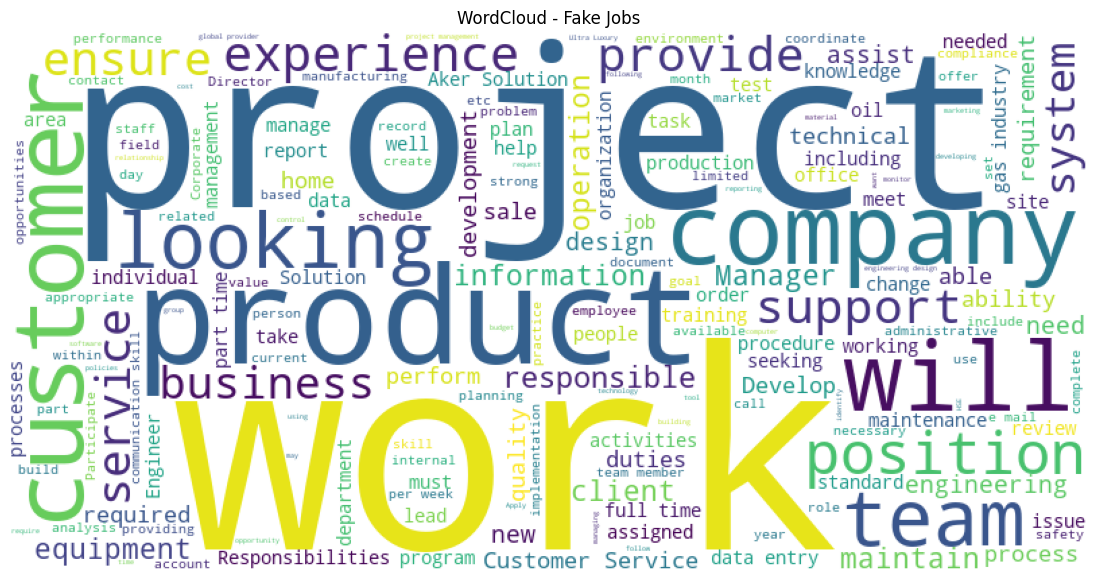

In [28]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(fake_text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("WordCloud - Fake Jobs")

plt.show()

In [29]:
df.groupby(
    'fraudulent'
)['company_profile'].apply(
    lambda x: x.isnull().sum()
)

fraudulent
0    2721
1     587
Name: company_profile, dtype: int64

In [30]:
df.groupby('fraudulent')['company_profile'] \
.apply(lambda x: x.isnull().mean() * 100)

fraudulent
0    15.992712
1    67.782910
Name: company_profile, dtype: float64

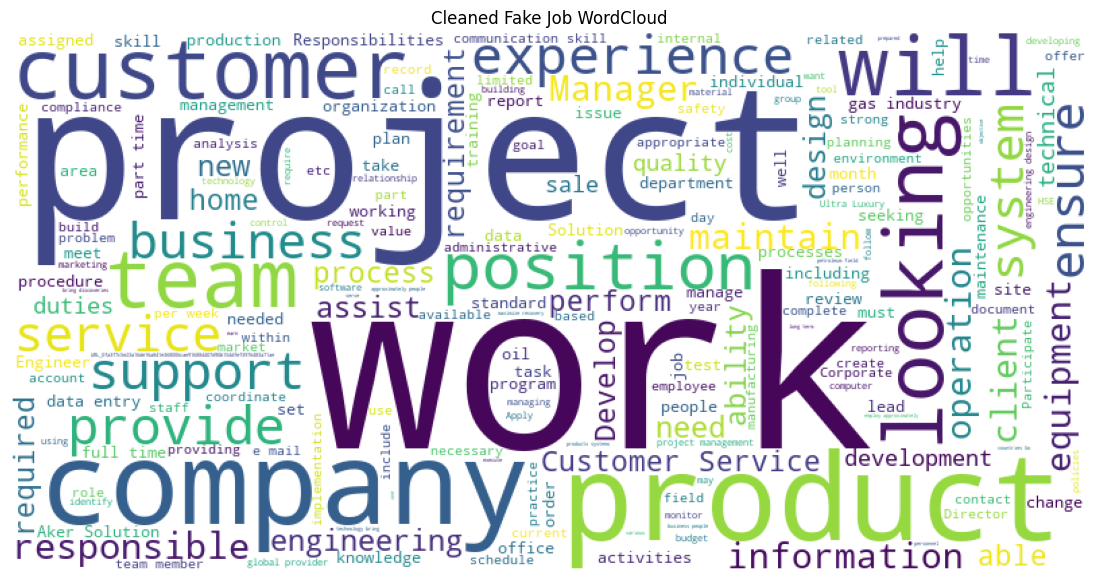

In [31]:
from wordcloud import STOPWORDS

stopwords = set(STOPWORDS)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords
).generate(fake_text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Cleaned Fake Job WordCloud")

plt.show()

In [33]:
from collections import Counter

words = [
    word for word in fake_text.lower().split()
    if word not in stopwords
]

common_words = Counter(words)

common_words.most_common(20)

[('work', 910),
 ('will', 617),
 ('&amp;', 596),
 ('-', 532),
 ('looking', 413),
 ('project', 412),
 ('customer', 411),
 ('team', 373),
 ('experience', 370),
 ('company', 369),
 ('position', 346),
 ('service', 342),
 ('within', 323),
 ('business', 321),
 ('new', 320),
 ('management', 318),
 ('support', 307),
 ('product', 294),
 ('data', 291),
 ('provide', 272)]